In [1]:
from datasets import load_dataset
import numpy as np

c:\Users\amal\sma-ss-llms\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("imdb")

In [13]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [14]:
train_df = ds['train'].to_pandas()

In [15]:
train_df.sample(10)

,text,label
3981,This film was just painful to watch... not in ...,0
2239,"The ""saucy"" misadventures of four au pairs who...",0
19464,"Putting the UFO ""thing"" aside. This was the be...",1
15926,While Rome goes mad celebrating Hitler's visit...,1
19117,Ever wonder where the ideas for romance novels...,1
8079,I watched this film last night with anticipati...,0
208,I watched Cabin by the Lake this afternoon on ...,0
1837,I have been a fervent Hal Hartley supporter si...,0
9869,People who actually liked Problem Child (1990)...,0
13603,i would like to comment the series as a great ...,1


In [16]:
train_df.label.value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [17]:
train_df['sentiment'] = np.where(train_df.label == 1, "positive", "negative")

In [18]:
train_df

,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative
2,If only to avoid making this type of film in t...,0,negative
3,This film was probably inspired by Godard's Ma...,0,negative
4,"Oh, brother...after hearing about this ridicul...",0,negative
...,...,...,...
24995,A hit at the time but now better categorised a...,1,positive
24996,I love this movie like no other. Another time ...,1,positive
24997,This film and it's sequel Barry Mckenzie holds...,1,positive
24998,'The Adventures Of Barry McKenzie' started lif...,1,positive


In [19]:
train_df.sentiment.value_counts()

sentiment
negative    12500
positive    12500
Name: count, dtype: int64

<Axes: >

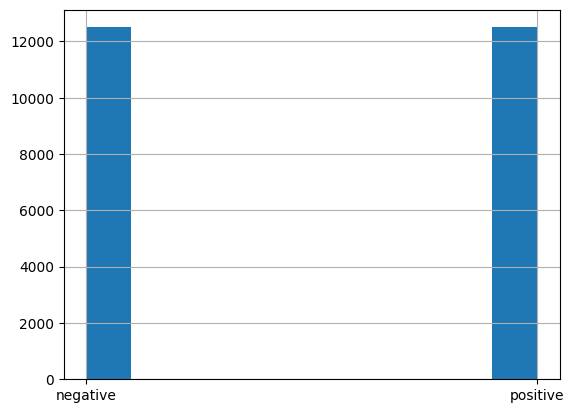

In [20]:
train_df.sentiment.hist()

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
examples_df, gold_examples_df = train_test_split(
    train_df, test_size=0.2, random_state=123
)

In [23]:
(examples_df.shape, gold_examples_df.shape)

((20000, 3), (5000, 3))

In [24]:
columns= ['text', 'sentiment']
gold_examples = ( 
    gold_examples_df.loc[:, columns]
    .sample(10, random_state=34 )
    .to_json(orient='records'))

In [25]:
import json

In [26]:
json.loads(gold_examples)[0]

{'text': '"A Guy Thing" may not be a classic, but it sure is a good, funny comedy. The plot focuses on Paul (Jason Lee), who wakes up the morning after his bachelor party with no memory and Becky (Julia Stiles) lying naked in his bed. Before he can figure out what happened, he rushes Becky out of his apartment because his fiance Karen (Selma Blair) is coming. After that, as you could imagine, chaos ensues.<br /><br />Almost every single scene in "A Guy Thing" delivers loud laughs. The funniest moments come from when Paul imagines what could happen if he tells Karen. Selma Blair is a truly talented comedian, and the worst thing about this film is that she goes underused. Although, she turns out to be more funny than Stiles\' character, who actually isn\'t that interesting. Of course, not every comedy is perfect.<br /><br />As I said, "A Guy Thing" is no classic, but it\'s not bad either, 7/10.',
 'sentiment': 'positive'}

In [27]:
user_message_template = """```{movie_review}```"""

In [28]:
zero_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks in the input.
Answer only 'positive' or 'negative' 
Do not explain your answer.
"""

In [29]:
zero_shot_prompt = [{'role':'system', 'content': zero_shot_system_message}]

In [30]:
few_shot_prompt_system = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
"""

In [31]:
examples_df.shape

(20000, 3)

In [32]:
positive_reviews_df = (examples_df[examples_df['sentiment'] == 'positive'][columns]
                       .sample(4)
)


In [33]:
positive_reviews_df

,text,sentiment
18326,I was quite surprised to read some of the comm...,positive
18434,This movie is sort of a Carrie meets Heavy Met...,positive
23237,"When I think about this movie, all the adjecti...",positive
15376,"""Cinderella"" is a film about a young girl whos...",positive


In [34]:
negative_reviews_df = (examples_df[examples_df['sentiment'] == 'negative'][columns]
                       .sample(4))

In [35]:
negative_reviews_df

,text,sentiment
4299,"This overrated, short-lived series (a measly t...",negative
9677,"Maaan, where do i start with this god awful mo...",negative
11957,I'd have to say that this was a little embarra...,negative
9979,I usually enjoy films like this. It's shot doc...,negative


In [36]:
positive_reviews_df.shape, negative_reviews_df.shape

((4, 2), (4, 2))

In [37]:
import pandas as pd

In [38]:
ex= pd.concat([positive_reviews_df, negative_reviews_df])

In [39]:
ex

,text,sentiment
18326,I was quite surprised to read some of the comm...,positive
18434,This movie is sort of a Carrie meets Heavy Met...,positive
23237,"When I think about this movie, all the adjecti...",positive
15376,"""Cinderella"" is a film about a young girl whos...",positive
4299,"This overrated, short-lived series (a measly t...",negative
9677,"Maaan, where do i start with this god awful mo...",negative
11957,I'd have to say that this was a little embarra...,negative
9979,I usually enjoy films like this. It's shot doc...,negative


In [40]:
examples = examples_df.sample(4*2, replace=False).to_json(orient='records')

In [41]:
json.loads(examples)

[{'text': "I can't say this is one of the best films I have ever seen. But then again, I can't say it's one of the worst I have ever seen.<br /><br />OK, so it's basically a girl does skating, is good at it, wants to go to an expensive school, can't afford it and has to take a Hockey Scholarship. She has to hide her skating secret from her friends.<br /><br />Personally, I didn't like the actress playing Katelin. She absolutely couldn't cry to save her life, just made wailing sounds, like a toddler pretending to cry to get it's own way.<br /><br />Katelin was just an annoying person. The way she tried to act all nice and helpful to people. Also the part where the two skaters are calling her names and they say something about her choreographer and she says she 'draws the line' made me cringe.<br /><br />We all knew where it was going to go with her and Spencer. Classically they didn't like each other and sort of get together at the end was just typical.<br /><br />Overall, I think this 

In [42]:
def create_examples(dataset, n=4):
    positive_reviews_df = (dataset[dataset['sentiment'] == 'positive']
                           .sample(n))
    negative_reviews_df = (dataset[dataset['sentiment'] == 'negative']
                           .sample(n))

    examples_df = pd.concat([positive_reviews_df, negative_reviews_df])
    examples = examples_df .sample(2*n, replace=False)
    return examples.to_json(orient='records')

In [43]:
examples_df.shape

(20000, 3)

In [45]:
few_shot_examples = create_examples(examples_df,n=2)

In [46]:
json.loads(few_shot_examples)

[{'text': 'They had an opportunity to make one of the best romantic tragedy mafia movies ever because they had the actors,the budget,and the story but the great director John Huston was too preoccupied trying to mellow out this missed classic.Strenuously trying to find black humor as often as possible which diluted the movie very much.And also they were so uncaring with details like sound and detailed action.Maybe it was the age of the director who passed away two years later.',
  'label': 0,
  'sentiment': 'negative'},
 {'text': 'Stan Laurel and Oliver Hardy are the most famous comedy duo in history, and deservedly so, so I am happy to see any of their films. Professor Noodle (Lucien Littlefield) is nearing the completion of his rejuvenation formula, with the ability to reverse ageing, after twenty years. Ollie and Stan are the chimney sweeps that arrive to do their job, and very quickly Ollie wants to get away from Stan making mistakes. Ollie goes to the roof to help with the other e

In [47]:
def create_prompt(system_message, examples, user_prompt_template):
    prompt = [{'role':'system', 'content': system_message}]

    for example in json.loads(examples):
        review = example['text']
        sentiment = example['sentiment']
        prompt.append(
            {
                'role': 'user',
                'content':user_prompt_template.format(movie_review=review)
            }
        )
        prompt.append(
            {'role': 'assistant', 'content': f"{sentiment}"}
        )
    return prompt

In [48]:
import json
few_shot_system_message = "You are a sentiment analysis assistant."
few_shot_examples = json.dumps([
    {"text": "This movie was amazing!", "sentiment": "positive"},
    {"text": "I hated this film.", "sentiment": "negative"}
])
user_message_template = "Analyze the sentiment of this review: {movie_review}"

few_shot_prompt = create_prompt(
    few_shot_system_message,
    few_shot_examples,
    user_message_template
)

In [49]:
few_shot_prompt

[{'role': 'system', 'content': 'You are a sentiment analysis assistant.'},
 {'role': 'user',
  'content': 'Analyze the sentiment of this review: This movie was amazing!'},
 {'role': 'assistant', 'content': 'positive'},
 {'role': 'user',
  'content': 'Analyze the sentiment of this review: I hated this film.'},
 {'role': 'assistant', 'content': 'negative'}]

In [50]:
cot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks ``` in the input.
Answer only 'positive' or 'negative' 
Do not explain your answer.

Instructions:
1. Carefully read the text of the review and think through the options for sentiment provided
2. Consider the overall sentiment of the review and estimate the probability of the review being positive

To reiterate, your answer should strictly only contain the label: positive or negative
"""

In [51]:
cot_few_shot_prompt = create_prompt(cot_system_message, examples, user_message_template)

In [52]:
cot_few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as 'positive' or 'negative'\nMovie reviews will be delimited by triple backticks ``` in the input.\nAnswer only 'positive' or 'negative' \nDo not explain your answer.\n\nInstructions:\n1. Carefully read the text of the review and think through the options for sentiment provided\n2. Consider the overall sentiment of the review and estimate the probability of the review being positive\n\nTo reiterate, your answer should strictly only contain the label: positive or negative\n"},
 {'role': 'user',
  'content': "Analyze the sentiment of this review: I can't say this is one of the best films I have ever seen. But then again, I can't say it's one of the worst I have ever seen.<br /><br />OK, so it's basically a girl does skating, is good at it, wants to go to an expensive school, can't afford it and has to take a Hockey Scholarship. She has to hide her skating secret from her friends.<br /><br /

In [53]:
from sklearn.metrics import f1_score

In [54]:
def evaluate_prompt(prompt, gold_examples, user_message_template, model):
    model_predictions, ground_truths = [], []

    for example in json.loads(gold_examples):
        gold_input = example['text']
        user_input = [
            {
                'role':'user',
                'content': user_message_template.format(movie_review=gold_input)
            }
        ]

        try:
            response = model.invoke(
               prompt+user_input
            )
            if hasattr (response, 'content'):
                response_content = response.content
            else:
                response_content = response    
            if 'negative' in response_content.strip().lower():
                prediction='negative'
            elif 'positive' in response_content.strip().lower():
                prediction='positive'
            else:
                prediction ='unknown'
            model_predictions.append(prediction)
            ground_truths.append(example['sentiment'])
            #print(prediction, example['sentiment'])

        except Exception as e:
            print(e)
            continue

    micro_f1_score = f1_score(ground_truths, model_predictions, average="micro")

    return micro_f1_score

In [55]:
from dotenv import load_dotenv

In [56]:
load_dotenv(override=True)

True

In [57]:
from langchain_openai import ChatOpenAI

c:\Users\amal\sma-ss-llms\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [58]:
llm1 = ChatOpenAI(model="gpt-4o", temperature=0)

In [59]:
evaluate_prompt(few_shot_prompt, gold_examples, user_message_template, llm1)

0.9

In [60]:
evaluate_prompt(zero_shot_prompt, gold_examples, user_message_template, llm1)

1.0

In [61]:
from langchain_ollama import ChatOllama

In [62]:
llm2 = ChatOllama(model="llama3.2",temperature=0)

In [63]:
evaluate_prompt(zero_shot_prompt, gold_examples, user_message_template, llm2)

1.0

In [64]:
from tqdm import tqdm

In [65]:
num_eval_runs = 5
few_shot_performance, cot_few_shot_performance = [], []
for _ in tqdm(range(num_eval_runs)):

    # For each run create a new sample of examples
    examples = create_examples(examples_df)

    # Assemble the few shot prompt with these examples
    few_shot_prompt = create_prompt(few_shot_system_message, examples, user_message_template)
    #cot_few_shot_prompt = create_prompt(cot_system_message, examples, user_message_template)

    # Evaluate prompt accuracy on gold examples
    few_shot_micro_f1 = evaluate_prompt(few_shot_prompt, gold_examples, user_message_template, llm2)
    #cot_few_shot_micro_f1 = evaluate_prompt(cot_few_shot_prompt, gold_examples, user_message_template)

    few_shot_performance.append(few_shot_micro_f1)
    cot_few_shot_performance.append(few_shot_micro_f1)


  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [2:34:10<00:00, 1850.12s/it]  


In [ ]:
#Tp 1 Use case du prompt Engineering : Sentiment Analysis